# Trabajo final · DSS de alerta temprana para tutoría

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Modalidad B (DSS) · Individual

Ejecuta el flujo completo: descarga verificada, auditoría, entrenamiento, decisión en validación, prueba, DSS y auditoría de equidad.

In [1]:
import json, os, subprocess, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
os.chdir(ROOT)
for script in ["download_data", "audit_data", "train", "audit_fairness"]:
    subprocess.run([sys.executable, f"scripts/{script}.py"], check=True, capture_output=True)
pd.set_option("display.max_colwidth", 100)

## 1. Auditoría de datos

In [2]:
json.loads(Path('reports/auditoria.json').read_text())

{'filas': 4424,
 'columnas': 39,
 'nulos': 0,
 'duplicados': 0,
 'clases': {'Graduate': 2209, 'Dropout': 1421, 'Enrolled': 794},
 'tasa_abandono': 0.3212,
 'abandono_por_genero': {'mujer': 0.251, 'hombre': 0.4505},
 'abandono_por_beca': {'sin beca': 0.3871, 'becario': 0.1219},
 'variables_modelo': 24,
 'variables_excluidas': ['Age at enrollment',
  'Curricular units 2nd sem (approved)',
  'Curricular units 2nd sem (credited)',
  'Curricular units 2nd sem (enrolled)',
  'Curricular units 2nd sem (evaluations)',
  'Curricular units 2nd sem (grade)',
  'Curricular units 2nd sem (without evaluations)',
  'Gender',
  'International',
  'Marital status',
  'Nacionality',
  'Scholarship holder']}

## 2. Baseline frente a modelo (validación y prueba)

In [3]:
display(pd.read_csv("reports/validacion.csv").round(3))
display(json.loads(Path("reports/decision.json").read_text()))
pd.read_csv("reports/prueba.csv").round(3)

,alternativa,seleccionados,aciertos,precision_capacidad,recall_capacidad,auc,average_precision
0,aleatorio,100,39,0.39,0.182,0.507,0.343
1,reglas,100,90,0.90,0.421,0.871,0.775
2,logistica,100,94,0.94,0.439,0.900,0.848


{'alternativa_elegida': 'logistica',
 'regla': 'mayor recall a capacidad en validación; desempate por average precision',
 'C': 1.0,
 'segundos_busqueda': 0.3263427080019028,
 'techo_recall_capacidad_prueba': 0.4694835680751174,
 'tomada_antes_de_prueba': True}

,alternativa,seleccionados,aciertos,precision_capacidad,recall_capacidad,auc,average_precision
0,aleatorio,100,30,0.30,0.141,0.482,0.309
1,reglas,100,83,0.83,0.390,0.868,0.777
2,logistica,100,97,0.97,0.455,0.916,0.874


## 3. Análisis de errores

In [4]:
pd.read_csv('reports/errores_perfil.csv', index_col=0).round(2)

,no alcanzado,alcanzado
Curricular units 1st sem (approved),3.43,0.91
Curricular units 1st sem (grade),9.04,4.39
Tuition fees up to date,0.84,0.43
Debtor,0.11,0.36
Admission grade,125.44,123.81
Curricular units 1st sem (enrolled),5.60,5.93


## 4. Lista que ve la coordinación

In [5]:
import joblib
from tutoria_dss.config import load_config
from tutoria_dss.data import load, split
from tutoria_dss.dss import prioritize
from tutoria_dss.fairness import audit_groups
from tutoria_dss.models import contributions, predict_risk
cfg = load_config(); model = joblib.load("models/logistica.joblib"); cohort = split(load())["test"]
prioritize(cohort, predict_risk(model, cohort), cfg["capacity_share"], contributions(model, cohort),
           audit_groups(cohort)["edad"]).head(10).round(3)

,prioridad,student_id,riesgo,apoyo_sugerido,por_que
0,1,E4404,1.000,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 1; matrícula al día = 0; carrera (código) = 9130
1,2,E1222,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; deuda con la institución = 1
2,3,E1850,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; modo de ingreso (código) = 7
3,4,E0678,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 1; matrícula al día = 0; ocupación de la madre (código) = 0
4,5,E3262,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; estudios de la madre (código) = 12
5,6,E1728,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; carrera (código) = 9254
6,7,E2448,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; deuda con la institución = 1
7,8,E4245,0.999,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; carrera (código) = 9853
8,9,E0255,0.998,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 1; matrícula al día = 0; deuda con la institución = 1
9,10,E0689,0.998,Orientación financiera + tutoría,unidades aprobadas 1.er semestre = 0; matrícula al día = 0; deuda con la institución = 1


## 5. Auditoría de equidad y decisión

,alternativa,recall_capacidad,precision_capacidad,brecha_genero,brecha_edad,brecha_beca
0,logistica,0.439,0.94,0.048,0.303,0.0
1,reglas,0.421,0.90,0.048,0.153,0.0
2,hibrido_rangos,0.444,0.95,0.018,0.236,0.0
3,logistica_cupos_edad,0.425,0.91,0.057,0.018,0.0


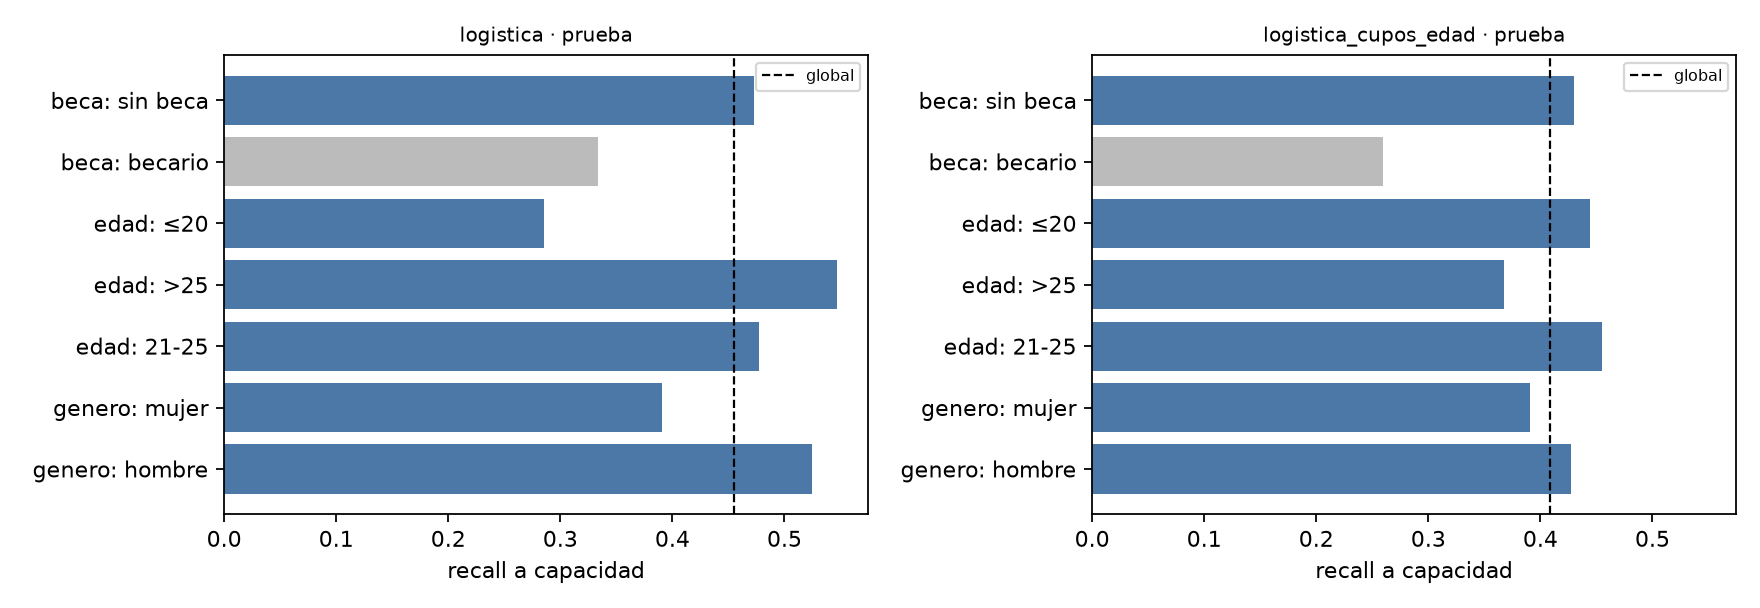

{'alternativa_elegida': 'logistica_cupos_edad',
 'decision': 'limitar',
 'recall_capacidad': 0.4084507042253521,
 'brechas': {'genero': 0.036275375110326524,
  'edad': 0.08662092624356776,
  'beca': 0.0},
 'limite_superior_ic95': {'genero': 0.1557963849468283,
  'edad': 0.19417011019283736,
  'beca': 0.29097619047619044},
 'green_ai': {'segundos_entrenamiento': 0.016803124999569263,
  'ms_por_estudiante': 0.00369112695829332,
  'tamano_modelo_kb': 10.5009765625,
  'parametros': 101,
  'hardware': 'CPU Apple M1 Pro'}}

In [6]:
display(pd.read_csv("reports/mitigacion_validacion.csv").round(3))
display(Image(filename="reports/equidad.png"))
final = json.loads(Path("reports/decision_final.json").read_text())
{k: final[k] for k in ["alternativa_elegida", "decision", "recall_capacidad", "brechas", "limite_superior_ic95", "green_ai"]}

## 6. Conclusión

La regresión logística alcanza 0.455 de recall a capacidad (techo 0.469) frente a 0.390 del baseline. Para no dejar fuera a los estudiantes jóvenes, los cupos se reparten por franja de edad (elegido en validación): recall 0.408 con brechas de 0.036 (género) y 0.087 (edad). Por la incertidumbre de la muestra, la decisión es **limitar**: piloto con revisión humana.